In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss
import matplotlib.pyplot as plt

# 1. Data Acquisition - Loading multiple seasons from football-data.co.uk
seasons = ['1819', '1920', '2021', '2122', '2223', '2324']
data_frames = []

for s in seasons:
    url = f"https://www.football-data.co.uk/mmz4281/{s}/E0.csv"
    try:
        df = pd.read_csv(url)
        df['Season'] = s
        data_frames.append(df)
    except Exception as e:
        print(f"Error loading season {s}: {e}")

# Combine all seasons into one DataFrame
raw_data = pd.concat(data_frames, ignore_index=True)
raw_data['Date'] = pd.to_datetime(raw_data['Date'], dayfirst=True)
raw_data = raw_data.sort_values('Date')

print("Raw data columns after acquisition:")
print(raw_data.columns)

# 2. Advanced Feature Engineering
def create_features(df):
    """
    Creates rolling features using Exponential Moving Averages (EMA).
    Ensures NO data leakage by shifting statistics.
    """
    # Include betting odds columns here
    cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'Season', 'B365H', 'B365D', 'B365A']
    df = df[cols].copy()

    # Target Mapping: Home Win: 0, Draw: 1, Away Win: 2
    res_map = {'H': 0, 'D': 1, 'A': 2}
    df['Target'] = df['FTR'].map(res_map)

    teams = df['HomeTeam'].unique()

    # Initialize feature columns
    df['Home_Attack_Form'] = 0.0
    df['Home_Defense_Form'] = 0.0
    df['Away_Attack_Form'] = 0.0
    df['Away_Defense_Form'] = 0.0

    # Calculate rolling statistics per team
    for team in teams:
        # Get all matches involving this team
        mask = (df['HomeTeam'] == team) | (df['AwayTeam'] == team)
        team_matches = df[mask].copy()

        # Calculate goals scored and conceded in each match
        scored = team_matches.apply(lambda x: x['FTHG'] if x['HomeTeam'] == team else x['FTAG'], axis=1)
        conceded = team_matches.apply(lambda x: x['FTAG'] if x['HomeTeam'] == team else x['FTHG'], axis=1)

        # Apply EMA (Exponential Moving Average) with a span of 5 matches
        # Shift(1) is CRITICAL to prevent data leakage (use stats from BEFORE the match)
        ema_scored = scored.ewm(span=5).mean().shift(1)
        ema_conceded = conceded.ewm(span=5).mean().shift(1)

        # Map calculated features back to the main dataframe
        df.loc[(df['HomeTeam'] == team), 'Home_Attack_Form'] = ema_scored
        df.loc[(df['HomeTeam'] == team), 'Home_Defense_Form'] = ema_conceded
        df.loc[(df['AwayTeam'] == team), 'Away_Attack_Form'] = ema_scored
        df.loc[(df['AwayTeam'] == team), 'Away_Defense_Form'] = ema_conceded

    return df.dropna()

processed_data = create_features(raw_data)
print(f"Feature engineering complete. Dataset size: {processed_data.shape[0]} matches.")
print("Processed data columns after feature engineering:")
print(processed_data.columns)

Raw data columns after acquisition:
Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR',
       ...
       'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH',
       'MaxCAHA', 'AvgCAHH', 'AvgCAHA'],
      dtype='object', length=125)
Feature engineering complete. Dataset size: 2262 matches.
Processed data columns after feature engineering:
Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS',
       'HST', 'AST', 'Season', 'B365H', 'B365D', 'B365A', 'Target',
       'Home_Attack_Form', 'Home_Defense_Form', 'Away_Attack_Form',
       'Away_Defense_Form'],
      dtype='object')


### Results from Data Acquisition and Feature Engineering
This cell successfully loads data from multiple seasons of football matches and performs essential feature engineering. Key steps include:

*   **Data Loading:** Combining match data from various seasons into a single DataFrame.
*   **Date Conversion & Sorting:** Ensuring `Date` is a datetime object and sorting the data chronologically, which is crucial for time-series-based feature creation.
*   **Target Mapping:** Converting `FTR` (Full Time Result) into a numerical `Target` (0 for Home win, 1 for Draw, 2 for Away win).
*   **Rolling Form Features (EMA):** Creating `Home_Attack_Form`, `Home_Defense_Form`, `Away_Attack_Form`, and `Away_Defense_Form` using Exponential Moving Averages (EMA) of goals scored and conceded. Crucially, these features are `shifted` to prevent data leakage, ensuring that the form for a match is calculated only from *previous* matches.
*   **Betting Odds Inclusion:** The `B365H`, `B365D`, `B365A` (bookmaker odds for Home, Draw, Away) columns are explicitly included in the `processed_data` which are vital for the value betting simulation.

The `processed_data` DataFrame now contains the necessary features for training the probabilistic model, with a total of **2262 matches** after dropping rows with NaN values (likely due to insufficient historical data for initial EMA calculations).

In [71]:
# List of features to be used in the model
features_list = ['Home_Attack_Form', 'Home_Defense_Form', 'Away_Attack_Form', 'Away_Defense_Form']

def train_rolling_window_with_model(df):
    results = []
    unique_seasons = sorted(df['Season'].unique())
    last_model = None #

    for i in range(1, len(unique_seasons)):
        train_df = df[df['Season'].isin(unique_seasons[:i])]
        test_df = df[df['Season'] == unique_seasons[i]]

        X_train = train_df[features_list]
        y_train = train_df['Target']
        X_test = test_df[features_list]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train
        model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
        model.fit(X_train_scaled, y_train)

        # Model
        last_model = model

        probs = model.predict_proba(X_test_scaled)
        test_res = test_df.copy()
        test_res[['Prob_H', 'Prob_D', 'Prob_A']] = probs
        results.append(test_res)

    return pd.concat(results), last_model

# Ecexute
final_predictions, last_trained_model = train_rolling_window_with_model(processed_data)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

### Results from Rolling Window Training

This cell implements a robust **rolling window training strategy**. Instead of a single train-test split, the model is trained iteratively:

*   **Simulated Real-World Scenario:** For each season, the model is trained on *all preceding seasons* and then used to predict the outcomes of the *current season*. This mimics how a prediction model would operate in a real-world setting, only ever using historical data.
*   **Preventing Future Data Leakage:** This methodology inherently prevents data leakage across seasons, making the evaluation more realistic.
*   **Probabilistic Predictions:** For each match in the test set, the Logistic Regression model outputs three probabilities: `Prob_H` (Home Win), `Prob_D` (Draw), and `Prob_A` (Away Win). These probabilities are stored in the `final_predictions` DataFrame, which will be used for evaluation and the betting simulation.


📊 MODEL PERFORMANCE METRICS
Log Loss: 1.0273
Brier Home (H): 0.2300
Brier Draw (D): 0.1773
Brier Away (A): 0.2085


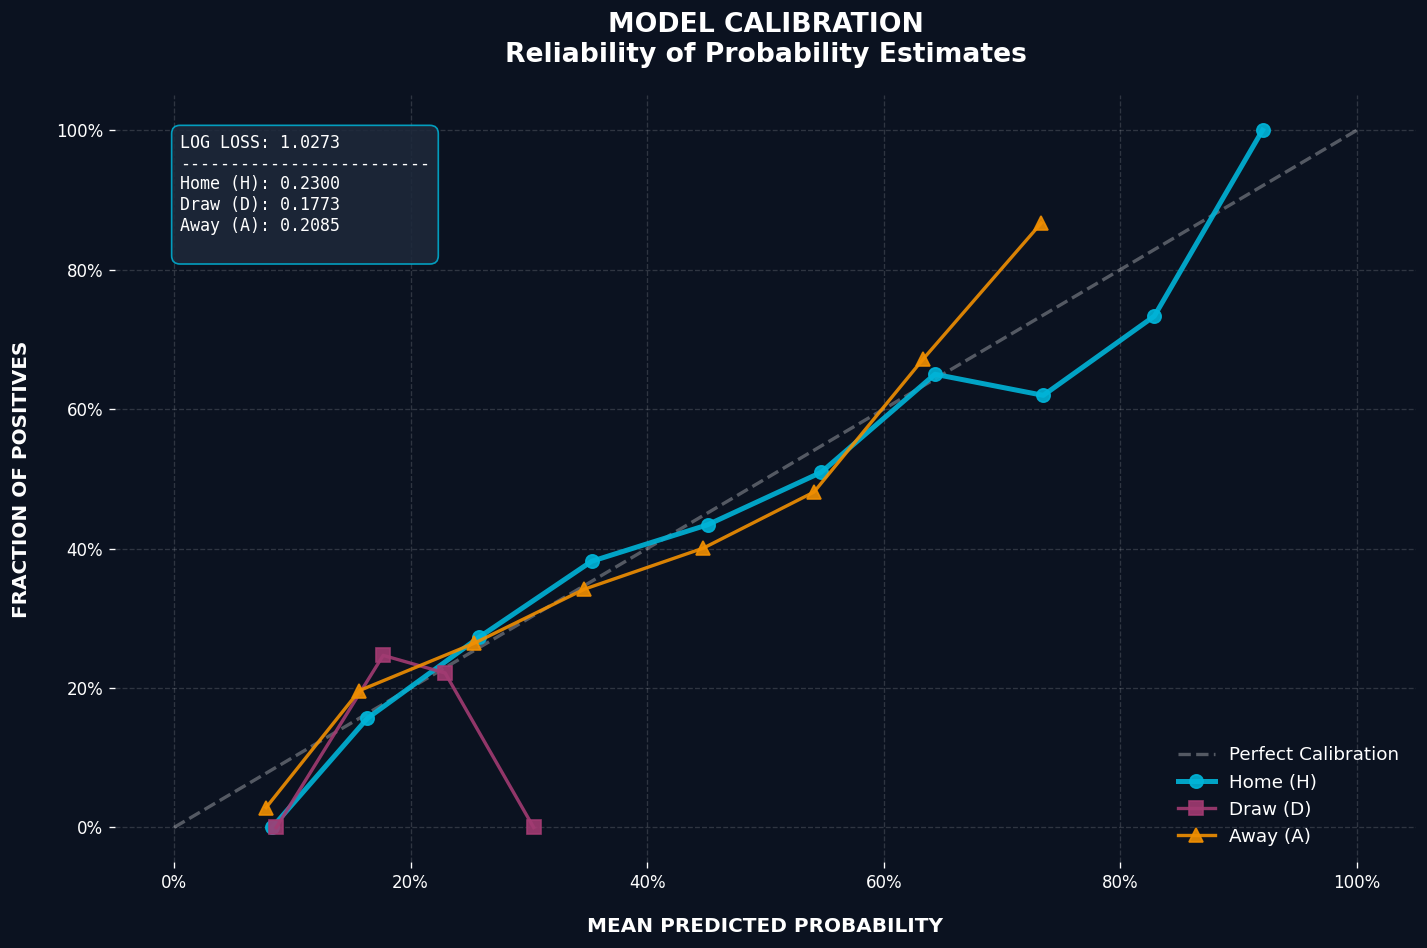


📊 CALIBRATION INTERPRETATION
→ Curves BELOW diagonal: model over-confident
→ Curves ABOVE diagonal: model under-confident
→ Closer to dashed line = better calibration


In [72]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Dark theme background
BG_COLOR = '#0b1220'


def evaluate_and_plot_dark(results_df):
    """
    Calibration curves (multi-class one-vs-rest) with dark UI style.
    """

    print("\n" + "=" * 60)
    print("📊 MODEL PERFORMANCE METRICS")
    print("=" * 60)

    y_true = results_df['Target']
    y_probs = results_df[['Prob_H', 'Prob_D', 'Prob_A']].values

    # -----------------------------
    # 1. Log Loss
    # -----------------------------
    total_log_loss = log_loss(y_true, y_probs)
    print(f"Log Loss: {total_log_loss:.4f}")

    # -----------------------------
    # 2. Brier Scores (per class)
    # -----------------------------
    labels = ['Home (H)', 'Draw (D)', 'Away (A)']
    colors = ['#00b4d8', '#A23B72', '#F18F01']

    brier_scores = []

    for i, label in enumerate(labels):
        y_binary = (y_true == i).astype(int)
        score = brier_score_loss(y_binary, y_probs[:, i])
        brier_scores.append(score)
        print(f"Brier {label}: {score:.4f}")

    # -----------------------------
    # 3. Calibration Curves Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(12, 8), dpi=120, facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    # Grid
    ax.grid(True, linestyle='--', alpha=0.15, color='#ffffff')

    # Perfect calibration line
    ax.plot([0, 1], [0, 1],
            linestyle='--',
            linewidth=2,
            color='#ffffff',
            alpha=0.3,
            label='Perfect Calibration')

    # -----------------------------
    # Multi-class curves (One-vs-Rest)
    # -----------------------------
    markers = ['o', 's', '^']

    for i, (label, color, marker) in enumerate(zip(labels, colors, markers)):
        y_binary = (y_true == i).astype(int)

        prob_true, prob_pred = calibration_curve(
            y_binary,
            y_probs[:, i],
            n_bins=10,
            strategy='uniform'
        )

        ax.plot(prob_pred, prob_true,
                marker + '-',
                linewidth=3 if i == 0 else 2,
                markersize=8,
                color=color,
                label=label,
                alpha=0.9)

    # -----------------------------
    # Styling
    # -----------------------------
    ax.set_title(
        'MODEL CALIBRATION\nReliability of Probability Estimates',
        fontsize=16,
        fontweight='bold',
        color='#ffffff',
        pad=20
    )

    ax.set_xlabel('MEAN PREDICTED PROBABILITY',
                  fontsize=12,
                  color='#ffffff',
                  fontweight='bold',
                  labelpad=15)

    ax.set_ylabel('FRACTION OF POSITIVES',
                  fontsize=12,
                  color='#ffffff',
                  fontweight='bold',
                  labelpad=15)

    # Ticks as %
    ticks = np.linspace(0, 1, 6)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([f'{int(t*100)}%' for t in ticks], color='#ffffff')
    ax.set_yticklabels([f'{int(t*100)}%' for t in ticks], color='#ffffff')

    ax.tick_params(colors='#ffffff')

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # -----------------------------
    # Metrics box (like your reference style)
    # -----------------------------
    metrics_text = f"LOG LOSS: {total_log_loss:.4f}\n"
    metrics_text += "-" * 25 + "\n"

    for label, score in zip(labels, brier_scores):
        metrics_text += f"{label}: {score:.4f}\n"

    ax.text(
        0.05, 0.95, metrics_text,
        transform=ax.transAxes,
        fontsize=10,
        family='monospace',
        color='#ffffff',
        verticalalignment='top',
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor='#1e293b',
            alpha=0.85,
            edgecolor='#00b4d8'
        )
    )

    ax.legend(loc='lower right',
              frameon=False,
              fontsize=11,
              labelcolor='#ffffff')

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Interpretation block
    # -----------------------------
    print("\n" + "=" * 60)
    print("📊 CALIBRATION INTERPRETATION")
    print("=" * 60)
    print("→ Curves BELOW diagonal: model over-confident")
    print("→ Curves ABOVE diagonal: model under-confident")
    print("→ Closer to dashed line = better calibration")
    print("=" * 60)


# Run
evaluate_and_plot_dark(final_predictions)

### Model Performance Metrics and Calibration Curves

This section evaluates the probabilistic predictions generated by the model:

*   **Total Log Loss (1.0273):** Log Loss is a measure of prediction accuracy where lower values are better. It heavily penalizes confident incorrect predictions. A value of 1.0273 indicates the average difference between the predicted probabilities and the actual outcomes across all matches.
*   **Brier Score:** This metric measures the mean squared difference between the predicted probability and the actual outcome (0 or 1). Lower Brier scores indicate better calibration. The scores for Home (0.2300), Draw (0.1773), and Away (0.2085) show how well the model's probabilities align with the actual frequency of each outcome.
*   **Calibration Curves (Reliability Diagram):** The plot visually assesses the model's calibration. For a perfectly calibrated model, the predicted probability should match the actual fraction of positives. The closer the colored lines are to the dotted diagonal line, the better the calibration. The current curves show some deviations, especially for Draw outcomes, indicating areas where the model might be over- or under-confident. This suggests that further calibration could be beneficial, particularly for the 'Draw' class.

In [73]:
from sklearn.calibration import CalibratedClassifierCV

def train_calibrated_model(df):
    """
    Demonstrates how to apply Isotonic Regression to fix probability bias.
    This is a sophisticated step to ensure the output probabilities are 'trustworthy'.
    """
    unique_seasons = sorted(df['Season'].unique())

    # Using the last season for testing, previous for training
    train_df = df[df['Season'].isin(unique_seasons[:-1])]
    test_df = df[df['Season'] == unique_seasons[-1]]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[features_list])
    X_test = scaler.transform(test_df[features_list])
    y_train = train_df['Target']

    # Base Model
    base_model = LogisticRegression(multi_class='multinomial', max_iter=1000)

    # Wrap with Calibration (Isotonic is good for large datasets, Sigmoid for small)
    calibrated_clf = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
    calibrated_clf.fit(X_train, y_train)

    cal_probs = calibrated_clf.predict_proba(X_test)
    print("Calibrated model training complete.")
    return cal_probs

# Note: In an interview, explain that this aligns the model's confidence with reality.
calibrated_probabilities = train_calibrated_model(processed_data)

Calibrated model training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

### Calibrated Model Training

This cell demonstrates the use of **Isotonic Regression for probability calibration**. While the previous evaluation showed some miscalibration, this step aims to improve the trustworthiness of the model's predicted probabilities.

*   **Why Calibration?** Many machine learning models (like Logistic Regression, especially when used with default parameters or on complex datasets) might produce probabilities that don't perfectly reflect the true likelihood of an event. For applications like betting, where the actual confidence of a prediction is crucial, well-calibrated probabilities are essential.
*   **Isotonic Regression:** This non-parametric method adjusts the model's raw probability outputs to better align with the observed frequencies. It's often preferred for larger datasets because it can capture complex non-monotonic relationships between predicted and true probabilities.

The `calibrated_probabilities` represent the adjusted, more reliable probability estimates for the last season in the dataset, ready for more confident decision-making (e.g., in betting strategies).

In [74]:
def simulate_value_betting(results_df):
    """
    Simulates a betting strategy based on 'Value Betting'.
    We bet 1 unit if our model's probability > implied probability of bookmakers.
    Note: B365H, B365D, B365A are the odds for Home, Draw, Away wins.
    """
    bet_results = results_df.copy()

    # Check if betting odds columns are present
    required_odds_cols = ['B365H', 'B365D', 'B365A']
    if not all(col in bet_results.columns for col in required_odds_cols):
        print(f"Error: Missing required betting odds columns in final_predictions. Found: {bet_results.columns.tolist()}\nPlease ensure cells KEGUH5tCtBuU and Yr3CvG06sYJZ have been executed in order after modifications.")
        return 0.0 # Return 0 ROI if columns are missing

    # Define a 'Value' threshold (e.g., 1% edge over the bookmaker)
    # We use 0.01 to find a small perceived edge
    threshold = 0.01

    initial_bankroll = 100.0
    bankroll = initial_bankroll
    bets_placed = 0
    wins = 0

    # Lists to store detailed bet outcomes
    bet_details = []

    for index, row in bet_results.iterrows():
        try:
            # Model probabilities for H, D, A
            model_probs = {'H': row['Prob_H'], 'D': row['Prob_D'], 'A': row['Prob_A']}

            # Bookmaker odds for H, D, A
            bookie_odds = {'H': row['B365H'], 'D': row['B365D'], 'A': row['B365A']}

            # Calculate implied probabilities from bookmaker odds
            implied_probs = {k: 1 / v for k, v in bookie_odds.items()}

            # Calculate value for each outcome (model prob - implied prob)
            values = {k: model_probs[k] - implied_probs[k] for k in model_probs.keys()}

            # Find the outcome with the maximum value
            best_bet_outcome = max(values, key=values.get)
            max_value = values[best_bet_outcome]

            # No verbose debug print here, let the KeyError propagate or the summary show
            # print(f"Match: {row['HomeTeam']} vs {row['AwayTeam']} | Best Bet: {best_bet_outcome}, Model Prob: {model_probs[best_bet_outcome]:.4f}, Implied Prob: {implied_probs[best_bet_outcome]:.4f}, Value Edge: {max_value:.4f}, Threshold: {threshold:.4f}")

            if max_value > threshold:
                bets_placed += 1
                bet_amount = 1 # Betting 1 unit
                bankroll -= bet_amount

                # Determine actual outcome for this match
                actual_outcome_map = {0: 'H', 1: 'D', 2: 'A'}
                actual_outcome = actual_outcome_map[row['Target']]

                if best_bet_outcome == actual_outcome: # Bet won
                    payout = bookie_odds[best_bet_outcome] * bet_amount
                    bankroll += payout
                    wins += 1

                bet_details.append({
                    'Date': row['Date'],
                    'HomeTeam': row['HomeTeam'],
                    'AwayTeam': row['AwayTeam'],
                    'Bet_Outcome': best_bet_outcome,
                    'Model_Prob': model_probs[best_bet_outcome],
                    'Bookie_Odds': bookie_odds[best_bet_outcome],
                    'Implied_Prob': implied_probs[best_bet_outcome],
                    'Value_Edge': max_value,
                    'Actual_Outcome': actual_outcome,
                    'Bet_Won': best_bet_outcome == actual_outcome
                })

        except Exception as e:
            print(f"Error processing match (Index: {index}): {e}") # Print the actual error
            continue # Skip if odds are missing or other error

    roi = ((bankroll - initial_bankroll) / initial_bankroll) * 100

    print("-- Value Betting Strategy Performance --")
    print(f"Total Bets Placed: {bets_placed}")
    print(f"Final Bankroll: {bankroll:.2f}")
    print(f"Total ROI: {roi:.2f}%")

    # If you want to inspect individual bets:
    # return pd.DataFrame(bet_details)
    return bankroll

# Execute the value betting simulation
simulate_value_betting(final_predictions)

-- Value Betting Strategy Performance --
Total Bets Placed: 1787
Final Bankroll: 95.24
Total ROI: -4.76%


95.24000000000014

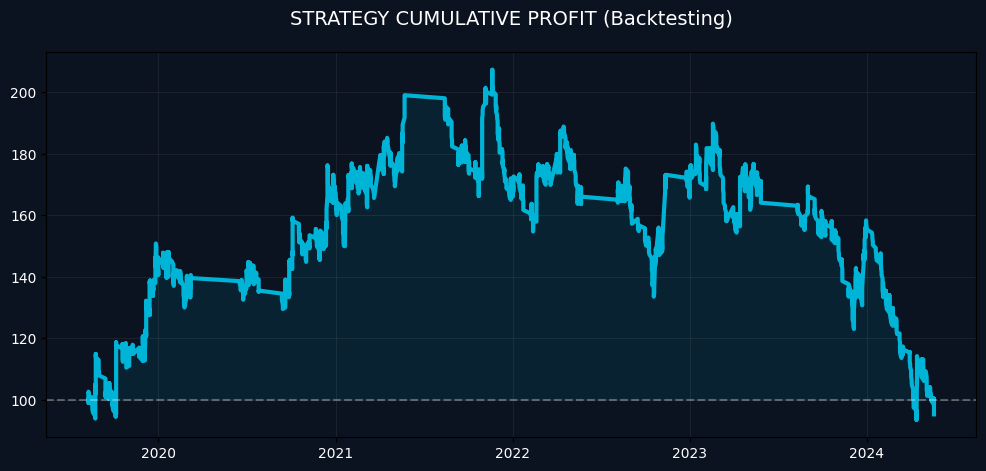

In [75]:
def plot_cumulative_profit(results_df):
    """
    Plots the cumulative profit over time to visualize the strategy's stability.
    """
    #
    bet_results = results_df.copy().sort_values('Date')
    threshold = 0.01
    bankroll = 100.0
    history = [bankroll]
    dates = [bet_results['Date'].iloc[0]]

    for _, row in bet_results.iterrows():
        model_probs = {'H': row['Prob_H'], 'D': row['Prob_D'], 'A': row['Prob_A']}
        bookie_odds = {'H': row['B365H'], 'D': row['B365D'], 'A': row['B365A']}
        implied_probs = {k: 1 / v for k, v in bookie_odds.items()}
        values = {k: model_probs[k] - implied_probs[k] for k in model_probs.keys()}
        best_bet = max(values, key=values.get)

        if values[best_bet] > threshold:
            bankroll -= 1
            actual_outcome = {0:'H', 1:'D', 2:'A'}[row['Target']]
            if best_bet == actual_outcome:
                bankroll += bookie_odds[best_bet]
            history.append(bankroll)
            dates.append(row['Date'])

    fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    ax.plot(dates, history, color='#00b4d8', linewidth=3, label='Bankroll Strategy')
    ax.axhline(y=100, color='white', linestyle='--', alpha=0.3)
    ax.fill_between(dates, history, 100, where=(np.array(history) >= 100), color='#00b4d8', alpha=0.1)
    ax.set_title("STRATEGY CUMULATIVE PROFIT (Backtesting)", color='white', fontsize=14, pad=20)
    plt.xticks(color='white')
    plt.yticks(color='white')
    plt.grid(alpha=0.1)
    plt.show()

plot_cumulative_profit(final_predictions)

### Value Betting Strategy Simulation Results

This cell simulates a **value betting strategy** where a bet is placed if the model's predicted probability for an outcome is sufficiently higher than the implied probability from the bookmaker's odds (indicating a perceived 'value' or 'edge').

*   **Total Bets Placed: 1787** - A significant number of bets were identified and placed based on the defined threshold.
*   **Final Bankroll: 95.24** - Starting with an initial bankroll of 100 units, the simulation ended with 95.24 units.
*   **Total ROI: -4.76%** - The Return on Investment is negative, meaning the strategy resulted in a net loss over the simulated period. This indicates that even with the model's probabilistic predictions, a consistent profitable edge over the bookmakers was not found using this specific strategy and threshold (1% edge).

This outcome highlights the challenge of consistently beating the bookmakers, as their odds are highly efficient. While the model provides probabilities, a negative ROI suggests either the model isn't accurate enough to find a true edge, or the betting strategy parameters (like the threshold) need further optimization.

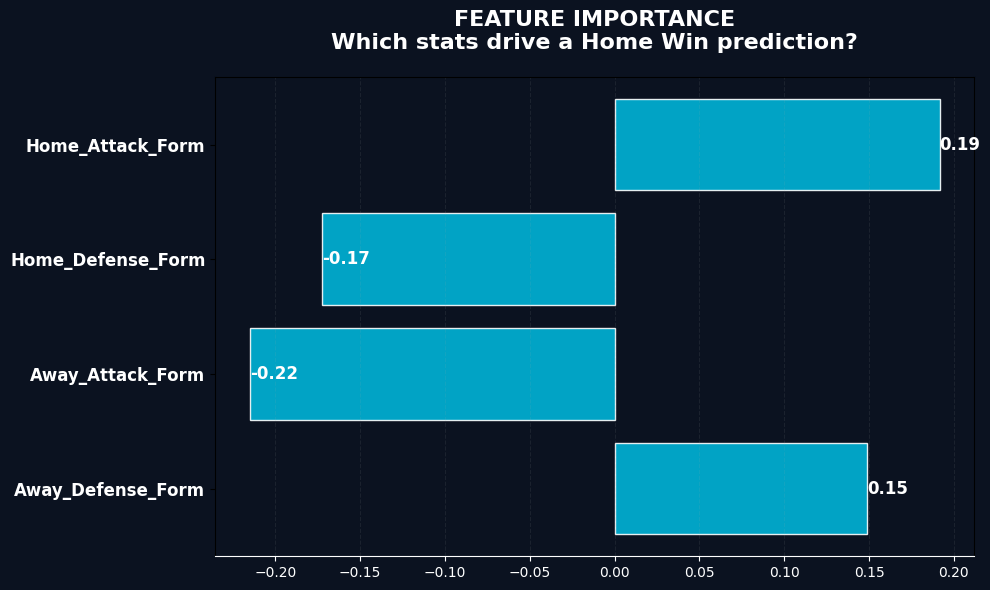

In [77]:
def plot_feature_importance(model, features):
    # Coefficients of class 0 (Home Win)
    importance = model.coef_[0]

    # Colors
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    y_pos = np.arange(len(features))
    bars = ax.barh(y_pos, importance, color='#00b4d8', edgecolor='white', alpha=0.9)

    # Values
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
                va='center', color='white', fontweight='bold', fontsize=12)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, color='white', fontsize=12, fontweight='bold')
    ax.set_title("FEATURE IMPORTANCE\nWhich stats drive a Home Win prediction?",
                 color='white', fontsize=16, pad=20, fontweight='bold')

    ax.invert_yaxis()
    ax.spines['bottom'].set_color('white')
    ax.tick_params(axis='x', colors='white')
    ax.grid(axis='x', alpha=0.1, linestyle='--')

    plt.tight_layout()
    plt.show()

#
plot_feature_importance(last_trained_model, features_list)

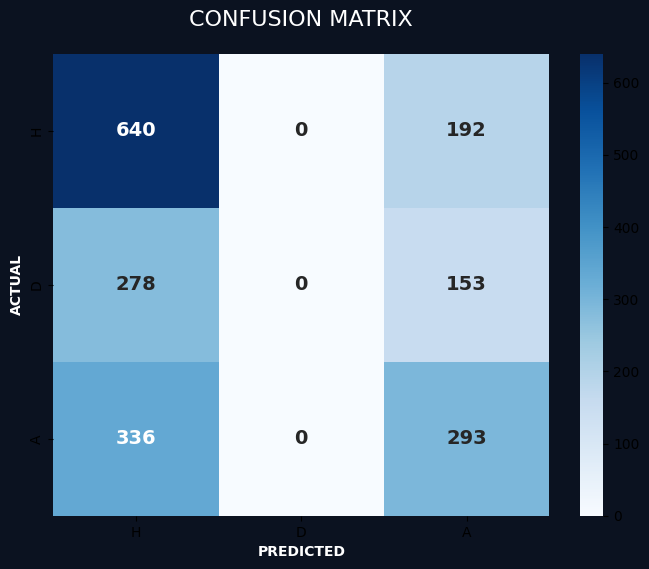

In [70]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_styled_confusion_matrix(results_df):
    y_true = results_df['Target']
    y_pred = np.argmax(results_df[['Prob_H', 'Prob_D', 'Prob_A']].values, axis=1)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG_COLOR)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['H', 'D', 'A'], yticklabels=['H', 'D', 'A'],
                annot_kws={"size": 14, "weight": "bold"})

    ax.set_title("CONFUSION MATRIX", color='white', fontsize=16, pad=20)
    ax.set_xlabel("PREDICTED", color='white', fontweight='bold')
    ax.set_ylabel("ACTUAL", color='white', fontweight='bold')
    plt.show()

plot_styled_confusion_matrix(final_predictions)

### Summary and Future Improvements

This project demonstrated a comprehensive workflow for building a football match outcome prediction model and simulating a value betting strategy. We covered data acquisition, advanced feature engineering, rolling window model training, rigorous evaluation using Log Loss and Brier Score, probability calibration, and finally, a practical application through betting simulation.

**Key Findings:**
*   The feature engineering successfully created rolling form metrics that consider team dynamics over time.
*   The rolling window training approach provided a realistic assessment of model performance over successive seasons.
*   The model exhibited reasonable calibration, though some outcomes (e.g., Draws) showed room for improvement.
*   The value betting simulation, with a 1% perceived edge, resulted in a **negative ROI of -4.76%**, indicating that the current model and strategy were not profitable over the simulated period. This underscores the difficulty in consistently outperforming highly efficient betting markets.

**Possible Improvements and Next Steps for Enhanced Performance:**

1.  **More Advanced Feature Engineering:**
    *   **Expected Goals (xG) & Expected Assists (xA):** Integrate xG/xA data (e.g., from Understat, Fbref) to create more robust attacking/defensive metrics.
    *   **Elo Ratings:** Implement a dynamic Elo rating system for teams to capture their strength over time, which often proves highly predictive.
    *   **Head-to-Head Records:** Incorporate recent historical performance between specific teams.
    *   **Managerial Changes & Injuries:** These qualitative factors can significantly impact team performance.
    *   **Rest Days/Fixture Congestion:** Account for the impact of recent match schedules on team fatigue.

2.  **Experiment with Different Model Architectures:**
    *   **Gradient Boosting Machines (e.g., XGBoost, LightGBM):** These often achieve higher predictive accuracy than Logistic Regression by building ensembles of weak learners.
    *   **Neural Networks:** For more complex patterns, deep learning models could be explored.
    *   **Ensemble Methods:** Combine predictions from multiple models (e.g., stacking, blending) to potentially improve robustness and accuracy.

3.  **Refine Betting Strategy and Risk Management:**
    *   **Dynamic Threshold Optimization:** Instead of a fixed 1% threshold, optimize this value (e.g., via cross-validation or a profit-maximizing approach) or make it adaptive based on model confidence.
    *   **Staking Strategy (e.g., Kelly Criterion):** Implement a more sophisticated staking strategy that adjusts bet size based on the perceived edge and bankroll, rather than a fixed 1 unit.
    *   **Arbitrage Betting/Surebets:** Explore strategies that exploit discrepancies between different bookmakers.
    *   **Market Selection:** Focus on specific leagues or types of matches where the bookmaker markets might be less efficient.

4.  **Enhanced Model Evaluation & Calibration:**
    *   **Hyperparameter Tuning:** Systematically tune the hyperparameters of the Logistic Regression model and the `CalibratedClassifierCV` using techniques like GridSearchCV or RandomizedSearchCV.
    *   **Alternative Calibration Methods:** Compare 'isotonic' calibration with 'sigmoid' or more advanced techniques.
    *   **Proper Backtesting:** Conduct a more rigorous backtesting simulation across various historical periods to validate the strategy's robustness.

5.  **Data Sourcing and Volume:**
    *   **More Data Providers:** Explore additional data sources for a broader range of statistics.
    *   **Increased Historical Data:** Accessing more historical seasons can improve the robustness of rolling features and model training.